<a href="https://colab.research.google.com/github/427paul/Machine_Learning/blob/main/DL_6_1_%EC%A2%85%ED%95%A9%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **종합실습**
* CIFAR-10 데이터 세트
    * AlexNet의 창시자 Alex krizhevsky가 수집하여 만든 데이터 셋
    * 10개 클래스에 32x32 컬러 이미지 60000개로 구성되어 있으며, 클래스당 6000개 이미지가 있습니다. 50000개의 훈련 이미지와 10000개의 테스트 이미지가 있습니다.
* 모델 평가 : accuracy score
    * 지금까지 배운 내용을 총 동원해서 accuracy를 높여 봅시다.

![](https://production-media.paperswithcode.com/datasets/4fdf2b82-2bc3-4f97-ba51-400322b228b1.png)


## 1.환경준비

### (1) 라이브러리 Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchsummary import summary

### (2) 필요 함수 생성

* 학습을 위한 함수

In [30]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)                  # 전체 데이터셋의 크기
    num_batches = len(dataloader)                   # 배치 크기
    tr_loss = 0
    model.train()                                   # 훈련 모드로 설정(드롭아웃 및 배치 정규화와 같은 계층을 훈련 모드로 변경)
    for batch, (X, y) in enumerate(dataloader):     # batch : 현재 배치 번호, (X, y) : 입력 데이터와 레이블
        X, y = X.to(device), y.to(device)           # X.to(device), y.to(device): 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지

    tr_loss /= num_batches          # 모든 배치에서의 loss 평균

    return tr_loss.item()

* 검증을 위한 함수

In [31]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정

    with torch.no_grad():               # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()    # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred

* 학습곡선

In [32]:
def dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list):

    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')
    plt.plot(epochs, val_acc_list, label='val_acc', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) device 준비(cpu or gpu)

In [29]:
# cpu 혹은 gpu 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### (4) 데이터 셋

#### 1) 다운로드

In [7]:
train_dataset = datasets.CIFAR10(root="./", train=True, download=True, transform=ToTensor())
test_dataset = datasets.CIFAR10(root="./", train=False, download=True, transform=ToTensor())

100%|██████████| 170M/170M [00:04<00:00, 37.3MB/s]


#### 2) 데이터셋 정보

* 데이터셋 일반 정보

In [8]:
train_dataset, test_dataset

(Dataset CIFAR10
     Number of datapoints: 50000
     Root location: ./
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset CIFAR10
     Number of datapoints: 10000
     Root location: ./
     Split: Test
     StandardTransform
 Transform: ToTensor())

* 데이터셋의 x와 y

* dataset.data : 구조가 이전과 다르다.
    * 파이토치가 받아들이는 구조 : (50000, 3, 32, 32)
    * 제공되는 구조 : (50000, 32, 32, 3)
        * data loader를 이용하면 자동으로 변환해줌 : (n, 3, 32, 32)

In [9]:
train_dataset.data.shape

(50000, 32, 32, 3)

* train_dataset.targets : 리스트

In [10]:
 train_dataset.targets[:10]

[6, 9, 9, 4, 1, 1, 2, 7, 8, 3]

* y(target)의 클래스

In [11]:
classes = train_dataset.classes
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

* 데이터 1건

In [12]:
train_dataset[0]

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
          [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
          [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
          ...,
          [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
          [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
          [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],
 
         [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
          [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
          [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
          ...,
          [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
          [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
          [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],
 
         [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
          [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
          [0.0824, 0.0000, 0.0314,  ...,

* 데이터 이미지 확인

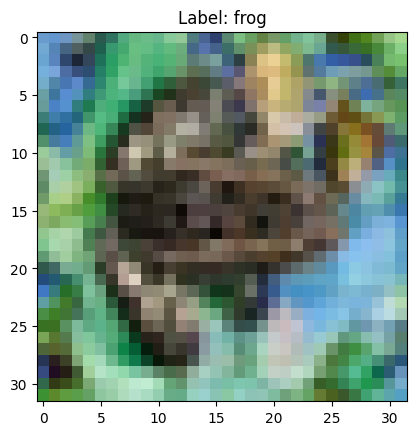

In [13]:
n = 200
image, label = train_dataset.data[n], train_dataset.targets[n]

# 이미지 시각화
plt.imshow(image)
plt.title(f"Label: {train_dataset.classes[label]}")
plt.show()

## 2.데이터 준비

* 다운 받은 데이터셋은 다음의 전처리가 완료됨
    * x, y가 분리
    * train, test 분리
    * 스케일링

### (1) train은 데이터로더로 생성

In [34]:
# 배치 사이즈를 지정해서 Data Loader로 선언하기
batch_size = 64
train_dataLoader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [35]:
# 첫번째 배치만 로딩해서 살펴보기
for temp_X, temp_y in train_dataLoader:
    print(f"Shape of X [N, C, H, W]: {temp_X.shape}")
    print(f"Shape of y: {temp_y.shape} {temp_y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 3, 32, 32])
Shape of y: torch.Size([64]) torch.int64


데이터 로더를 통과한 데이터의 결과를 보면 [64, 3, 32, 32]

### (2) validation, test 준비
* 데이터셋 분할
    * validation : 학습시, 에포크마다 성능 검증용
    * test : 모델 생성 후 최종 검증용
* dataset의 data 속성으로 데이터를 뽑으면 원본데이터가 나옵니다.
    * 스케일링 안된 데이터
    * **5000, 28, 28, 3** : 채널 차원이 뒤에 나옴.
* 그래서 모델링에 사용하려면 두가지 전처리를 다시 해줘야 함
    * 스케일링 : 원본데이터가 0~255 까지 숫자이므로, 255로 나눠주면 됨
    * 차원 위치 변환 : **5000, 3, 28, 28**

In [36]:
# 1) 데이터와 레이블 추출
test_data = test_dataset.data  # x : (10000, 32, 32, 3)
test_targets = np.array(test_dataset.targets) # y

# 2) 데이터 위치 조정 : [n(0), 세로픽셀(1), 가로픽셀(2), 채널(3)] -> [n(0), 채널(3), 세로픽셀(1), 가로픽셀(2)]
test_data = test_data.transpose((0, 3, 1, 2))  # (10000, 3, 32, 32)

# 3) 텐서로 변환
test_data = torch.tensor(test_data, dtype=torch.float32)
test_targets = torch.tensor(test_targets, dtype=torch.int64)


# 변환된 데이터의 형태 확인
test_data.shape, test_targets.shape


(torch.Size([10000, 3, 32, 32]), torch.Size([10000]))

In [37]:
# 4) 텐서 데이터셋을 validation 5000건, test 5000건으로 나누기
x_val, x_test = test_data[:5000], test_data[:5000]
y_val, y_test = test_targets[:5000], test_targets[:5000]

In [38]:
# x_val, y_val, x_test, y_test의 shape 확인
x_val.shape, y_val.shape, x_test.shape, y_test.shape

(torch.Size([5000, 3, 32, 32]),
 torch.Size([5000]),
 torch.Size([5000, 3, 32, 32]),
 torch.Size([5000]))

* 스케일링

In [39]:
x_val = x_val / 255.0
x_test = x_test / 255.0

## 3.모델링1 : MNIST와 동일한 구조
* Sequential과 Class 선언방식 모두 작성해 봅시다.

### (1) 모델 선언

In [40]:
# 모델 구조 설계
n_class = 10

model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size = 3, stride = 1, padding = 1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size = 2, stride = 2),

    nn.Conv2d(32, 64, kernel_size = 3, stride = 1, padding = 1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size = 2, stride = 2),

    nn.Flatten(),
    nn.Linear(64*8*8, 128),
    nn.ReLU(),
    nn.Linear(128, n_class)

).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = 0.001)
# 모델 요약
summary(model, input_size = (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
              ReLU-2           [-1, 32, 32, 32]               0
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
              ReLU-5           [-1, 64, 16, 16]               0
         MaxPool2d-6             [-1, 64, 8, 8]               0
           Flatten-7                 [-1, 4096]               0
            Linear-8                  [-1, 128]         524,416
              ReLU-9                  [-1, 128]               0
           Linear-10                   [-1, 10]           1,290
Total params: 545,098
Trainable params: 545,098
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.88
Params size (MB): 2.08
Estimated T

In [41]:
class CustomCNN1(nn.Module):
  def __init__(self, n_class):
    super(CustomCNN1, self).__init__()
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.fc1 = nn.Linear(64 * 8 * 8, 128)
    self.fc2 = nn.Linear(128, n_class)
    self.flat = nn.Flatten()
    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.pool(x)

    x = self.conv2(x)
    x = self.relu(x)
    x = self.pool(x)

    x = self.flat(x)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)

    return x

### (2) 학습

In [44]:
epochs = 10
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_dataLoader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val, y_val, model, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}")

Epoch 1, train loss : 1.4914, val loss : 1.2139
Epoch 2, train loss : 1.1336, val loss : 1.0676
Epoch 3, train loss : 0.9920, val loss : 0.9843
Epoch 4, train loss : 0.8925, val loss : 0.9433
Epoch 5, train loss : 0.8213, val loss : 0.9002
Epoch 6, train loss : 0.7557, val loss : 0.9071
Epoch 7, train loss : 0.6972, val loss : 0.8801
Epoch 8, train loss : 0.6471, val loss : 0.8810
Epoch 9, train loss : 0.5994, val loss : 0.8715
Epoch 10, train loss : 0.5450, val loss : 0.9127


### (3) 모델 평가

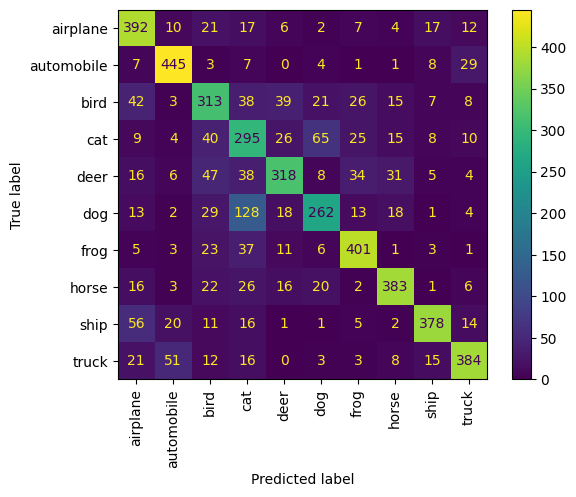

0.7142
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.68      0.80      0.74       488
           1       0.81      0.88      0.85       505
           2       0.60      0.61      0.61       512
           3       0.48      0.59      0.53       497
           4       0.73      0.63      0.68       507
           5       0.67      0.54      0.60       488
           6       0.78      0.82      0.80       491
           7       0.80      0.77      0.79       495
           8       0.85      0.75      0.80       504
           9       0.81      0.75      0.78       513

    accuracy                           0.71      5000
   macro avg       0.72      0.71      0.71      5000
weighted avg       0.72      0.71      0.72      5000



In [45]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1) # 예측 결과를 softmax를 이용하여 확률로 변환
pred = np.argmax(pred.cpu().numpy(), axis = 1) # argmax로 확률 중 가장 큰 확률 선택
# gpu 연산 결과를 numpy 변환을 위해 cpu 변환을 거침

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
# confusion matrix 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = train_dataset.classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print(accuracy_score(y_test.numpy(), pred))
print('-'*100)
print(classification_report(y_test.numpy(), pred))

## 4.모델링2 : 보다 복잡한 모델링
* Sequential과 Class 선언방식 모두 작성해 봅시다.

### (1) 모델 선언

In [47]:
# 모델 구조 설계
n_class = 10

model = nn.Sequential(
    nn.Conv2d(3, 64, kernel_size = 3, stride = 1, padding = 1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size = 2, stride = 2),

    nn.Conv2d(64, 128, kernel_size = 3, stride = 1, padding = 1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size = 2, stride = 2),

    nn.Conv2d(128, 256, kernel_size = 3, stride = 1, padding = 1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size = 2, stride = 2),

    nn.Flatten(),
    nn.Linear(256*4*4, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Linear(64, n_class)

).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = 0.001)
# 모델 요약
summary(model, input_size = (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 128, 16, 16]          73,856
              ReLU-5          [-1, 128, 16, 16]               0
         MaxPool2d-6            [-1, 128, 8, 8]               0
            Conv2d-7            [-1, 256, 8, 8]         295,168
              ReLU-8            [-1, 256, 8, 8]               0
         MaxPool2d-9            [-1, 256, 4, 4]               0
          Flatten-10                 [-1, 4096]               0
           Linear-11                  [-1, 512]       2,097,664
             ReLU-12                  [-1, 512]               0
           Linear-13                  [-1, 256]         131,328
             ReLU-14                  [

In [48]:
class CustomCNN1(nn.Module):
  def __init__(self, n_class):
    super(CustomCNN1, self).__init__()
    self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
    self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
    self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.fc1 = nn.Linear(256 * 4 * 4, 512)
    self.fc2 = nn.Linear(512, 256)
    self.fc3 = nn.Linear(256, 64)
    self.fc4 = nn.Linear(64, n_class)
    self.flat = nn.Flatten()
    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.pool(x)

    x = self.conv2(x)
    x = self.relu(x)
    x = self.pool(x)

    x = self.conv3(x)
    x = self.relu(x)
    x = self.pool(x)

    x = self.flat(x)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    x = self.relu(x)
    x = self.fc3(x)
    x = self.relu(x)
    x = self.fc4(x)

    return x

### (2) 학습

In [49]:
epochs = 20
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_dataLoader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val, y_val, model, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}")

Epoch 1, train loss : 1.5522, val loss : 1.2408
Epoch 2, train loss : 1.0871, val loss : 1.0878
Epoch 3, train loss : 0.8653, val loss : 0.8426
Epoch 4, train loss : 0.7087, val loss : 0.8011
Epoch 5, train loss : 0.5796, val loss : 0.7887
Epoch 6, train loss : 0.4767, val loss : 0.7583
Epoch 7, train loss : 0.3816, val loss : 0.8239
Epoch 8, train loss : 0.2953, val loss : 0.8921
Epoch 9, train loss : 0.2399, val loss : 0.9958
Epoch 10, train loss : 0.1937, val loss : 1.0901
Epoch 11, train loss : 0.1601, val loss : 1.1885
Epoch 12, train loss : 0.1291, val loss : 1.2008
Epoch 13, train loss : 0.1219, val loss : 1.1762
Epoch 14, train loss : 0.1053, val loss : 1.3874
Epoch 15, train loss : 0.0946, val loss : 1.3743
Epoch 16, train loss : 0.0887, val loss : 1.2675
Epoch 17, train loss : 0.0781, val loss : 1.4522
Epoch 18, train loss : 0.0839, val loss : 1.3844
Epoch 19, train loss : 0.0730, val loss : 1.4486
Epoch 20, train loss : 0.0674, val loss : 1.5107


### (3) 모델 평가

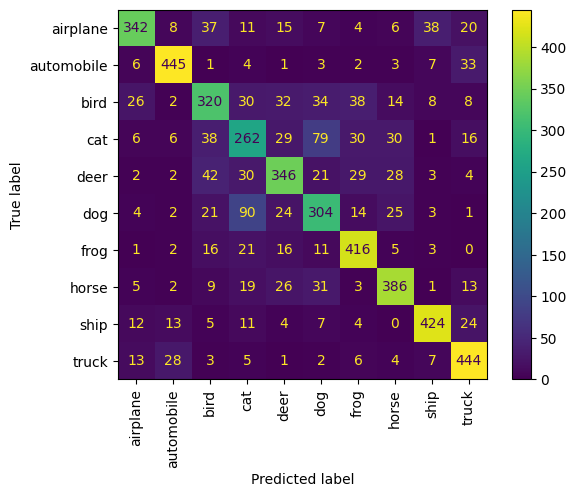

0.7378
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.70      0.76       488
           1       0.87      0.88      0.88       505
           2       0.65      0.62      0.64       512
           3       0.54      0.53      0.53       497
           4       0.70      0.68      0.69       507
           5       0.61      0.62      0.62       488
           6       0.76      0.85      0.80       491
           7       0.77      0.78      0.78       495
           8       0.86      0.84      0.85       504
           9       0.79      0.87      0.83       513

    accuracy                           0.74      5000
   macro avg       0.74      0.74      0.74      5000
weighted avg       0.74      0.74      0.74      5000



In [50]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1) # 예측 결과를 softmax를 이용하여 확률로 변환
pred = np.argmax(pred.cpu().numpy(), axis = 1) # argmax로 확률 중 가장 큰 확률 선택
# gpu 연산 결과를 numpy 변환을 위해 cpu 변환을 거침

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
# confusion matrix 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = train_dataset.classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print(accuracy_score(y_test.numpy(), pred))
print('-'*100)
print(classification_report(y_test.numpy(), pred))

## 5.모델링3 : dropout 추가
* Sequential과 Class 선언방식 모두 작성해 봅시다.

### (1) 모델 선언

In [51]:
# 모델 구조 설계
n_class = 10
dropout_rate = 0.3

model = nn.Sequential(
    nn.Conv2d(3, 64, kernel_size = 3, stride = 1, padding = 1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size = 2, stride = 2),
    nn.Dropout(dropout_rate),

    nn.Conv2d(64, 128, kernel_size = 3, stride = 1, padding = 1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size = 2, stride = 2),
    nn.Dropout(dropout_rate),

    nn.Conv2d(128, 256, kernel_size = 3, stride = 1, padding = 1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size = 2, stride = 2),
    nn.Dropout(dropout_rate),

    nn.Flatten(),
    nn.Linear(256*4*4, 512),
    nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(64, n_class)

).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = 0.001)
# 모델 요약
summary(model, input_size = (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
           Dropout-4           [-1, 64, 16, 16]               0
            Conv2d-5          [-1, 128, 16, 16]          73,856
              ReLU-6          [-1, 128, 16, 16]               0
         MaxPool2d-7            [-1, 128, 8, 8]               0
           Dropout-8            [-1, 128, 8, 8]               0
            Conv2d-9            [-1, 256, 8, 8]         295,168
             ReLU-10            [-1, 256, 8, 8]               0
        MaxPool2d-11            [-1, 256, 4, 4]               0
          Dropout-12            [-1, 256, 4, 4]               0
          Flatten-13                 [-1, 4096]               0
           Linear-14                  [

In [52]:
class CustomCNN1(nn.Module):
  def __init__(self, n_class):
    super(CustomCNN1, self).__init__()
    self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
    self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
    self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.fc1 = nn.Linear(256 * 4 * 4, 512)
    self.fc2 = nn.Linear(512, 256)
    self.fc3 = nn.Linear(256, 64)
    self.fc4 = nn.Linear(64, n_class)
    self.flat = nn.Flatten()
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(dropout_rate)

  def forward(self, x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.pool(x)
    x = self.dropout(x)

    x = self.conv2(x)
    x = self.relu(x)
    x = self.pool(x)
    x = self.dropout(x)

    x = self.conv3(x)
    x = self.relu(x)
    x = self.pool(x)
    x = self.dropout(x)

    x = self.flat(x)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.fc2(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.fc3(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.fc4(x)

    return x

### (2) 학습

In [53]:
epochs = 20
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_dataLoader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val, y_val, model, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}")

Epoch 1, train loss : 1.7916, val loss : 1.4100
Epoch 2, train loss : 1.3939, val loss : 1.1751
Epoch 3, train loss : 1.2342, val loss : 1.0766
Epoch 4, train loss : 1.1347, val loss : 1.0167
Epoch 5, train loss : 1.0504, val loss : 1.0119
Epoch 6, train loss : 1.0023, val loss : 0.8585
Epoch 7, train loss : 0.9519, val loss : 0.8238
Epoch 8, train loss : 0.9214, val loss : 0.8241
Epoch 9, train loss : 0.8837, val loss : 0.8073
Epoch 10, train loss : 0.8631, val loss : 0.7672
Epoch 11, train loss : 0.8302, val loss : 0.7483
Epoch 12, train loss : 0.8142, val loss : 0.7315
Epoch 13, train loss : 0.7881, val loss : 0.7687
Epoch 14, train loss : 0.7775, val loss : 0.7719
Epoch 15, train loss : 0.7560, val loss : 0.7240
Epoch 16, train loss : 0.7485, val loss : 0.6886
Epoch 17, train loss : 0.7290, val loss : 0.7085
Epoch 18, train loss : 0.7153, val loss : 0.6844
Epoch 19, train loss : 0.7037, val loss : 0.7376
Epoch 20, train loss : 0.6931, val loss : 0.6941


### (3) 모델 평가

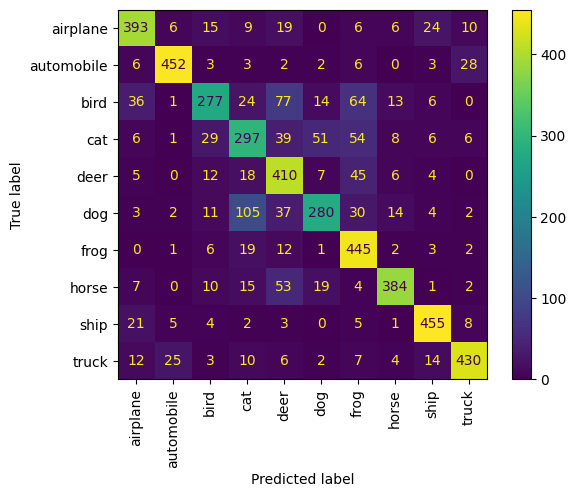

0.7646
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.80      0.81      0.80       488
           1       0.92      0.90      0.91       505
           2       0.75      0.54      0.63       512
           3       0.59      0.60      0.59       497
           4       0.62      0.81      0.70       507
           5       0.74      0.57      0.65       488
           6       0.67      0.91      0.77       491
           7       0.88      0.78      0.82       495
           8       0.88      0.90      0.89       504
           9       0.88      0.84      0.86       513

    accuracy                           0.76      5000
   macro avg       0.77      0.76      0.76      5000
weighted avg       0.77      0.76      0.76      5000



In [54]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1) # 예측 결과를 softmax를 이용하여 확률로 변환
pred = np.argmax(pred.cpu().numpy(), axis = 1) # argmax로 확률 중 가장 큰 확률 선택
# gpu 연산 결과를 numpy 변환을 위해 cpu 변환을 거침

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
# confusion matrix 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = train_dataset.classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print(accuracy_score(y_test.numpy(), pred))
print('-'*100)
print(classification_report(y_test.numpy(), pred))